In [ ]:
import struct
import numpy as np

def load_idx_images(path):
    with open(path, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num, rows, cols)
    return images

def load_idx_labels(path):
    with open(path, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    return labels

def rotate(images):
    images = np.transpose(images, (0, 2, 1))
    images = np.flip(images, axis=2)
    return images

train_images = load_idx_images('../data/original/emnist-byclass-train-images-idx3-ubyte')
train_labels = load_idx_labels('../data/original/emnist-byclass-train-labels-idx1-ubyte')
test_images = load_idx_images('../data/original/emnist-byclass-test-images-idx3-ubyte')
test_labels = load_idx_labels('../data/original/emnist-byclass-test-labels-idx1-ubyte')

train_images = rotate(train_images)
test_images = rotate(test_images)

mapping = {}
# Digits
for i in range(10):
    mapping[i] = str(i)
# Lowercase letters
for i in range(26):
    mapping[10 + i] = chr(65 + i)
# Uppercase letters
for i in range(26):
    mapping[36 + i] = chr(97 + i)

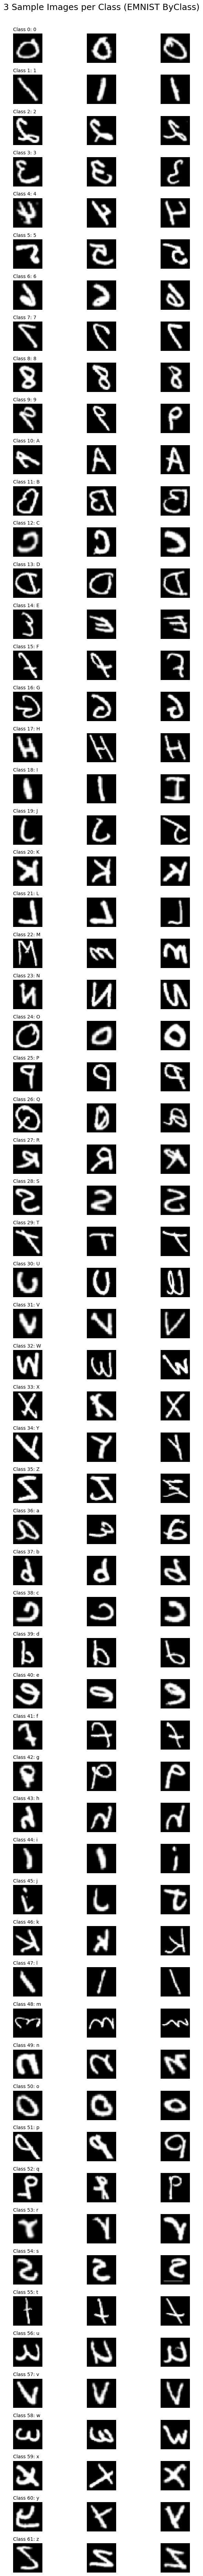

In [24]:
import matplotlib.pyplot as plt
import numpy as np

num_classes = 62
samples_per_class = 3

fig, axes = plt.subplots(
    num_classes, samples_per_class,
    figsize=(samples_per_class * 2.5, num_classes * 1.2)
)

for c in range(num_classes):
    idx = np.where(train_labels == c)[0]

    chosen = idx[:samples_per_class]

    for j in range(samples_per_class):
        ax = axes[c, j]
        ax.axis('off')

        if j < len(chosen):
            ax.imshow(train_images[chosen[j]], cmap='gray')

        if j == 0:
            ax.set_title(
                f"Class {c}: {mapping[c]}",
                fontsize=10,
                loc='left'
            )

plt.suptitle(
    "3 Sample Images per Class (EMNIST ByClass)",
    fontsize=18,
    y=1.002
)
plt.tight_layout()
plt.show()


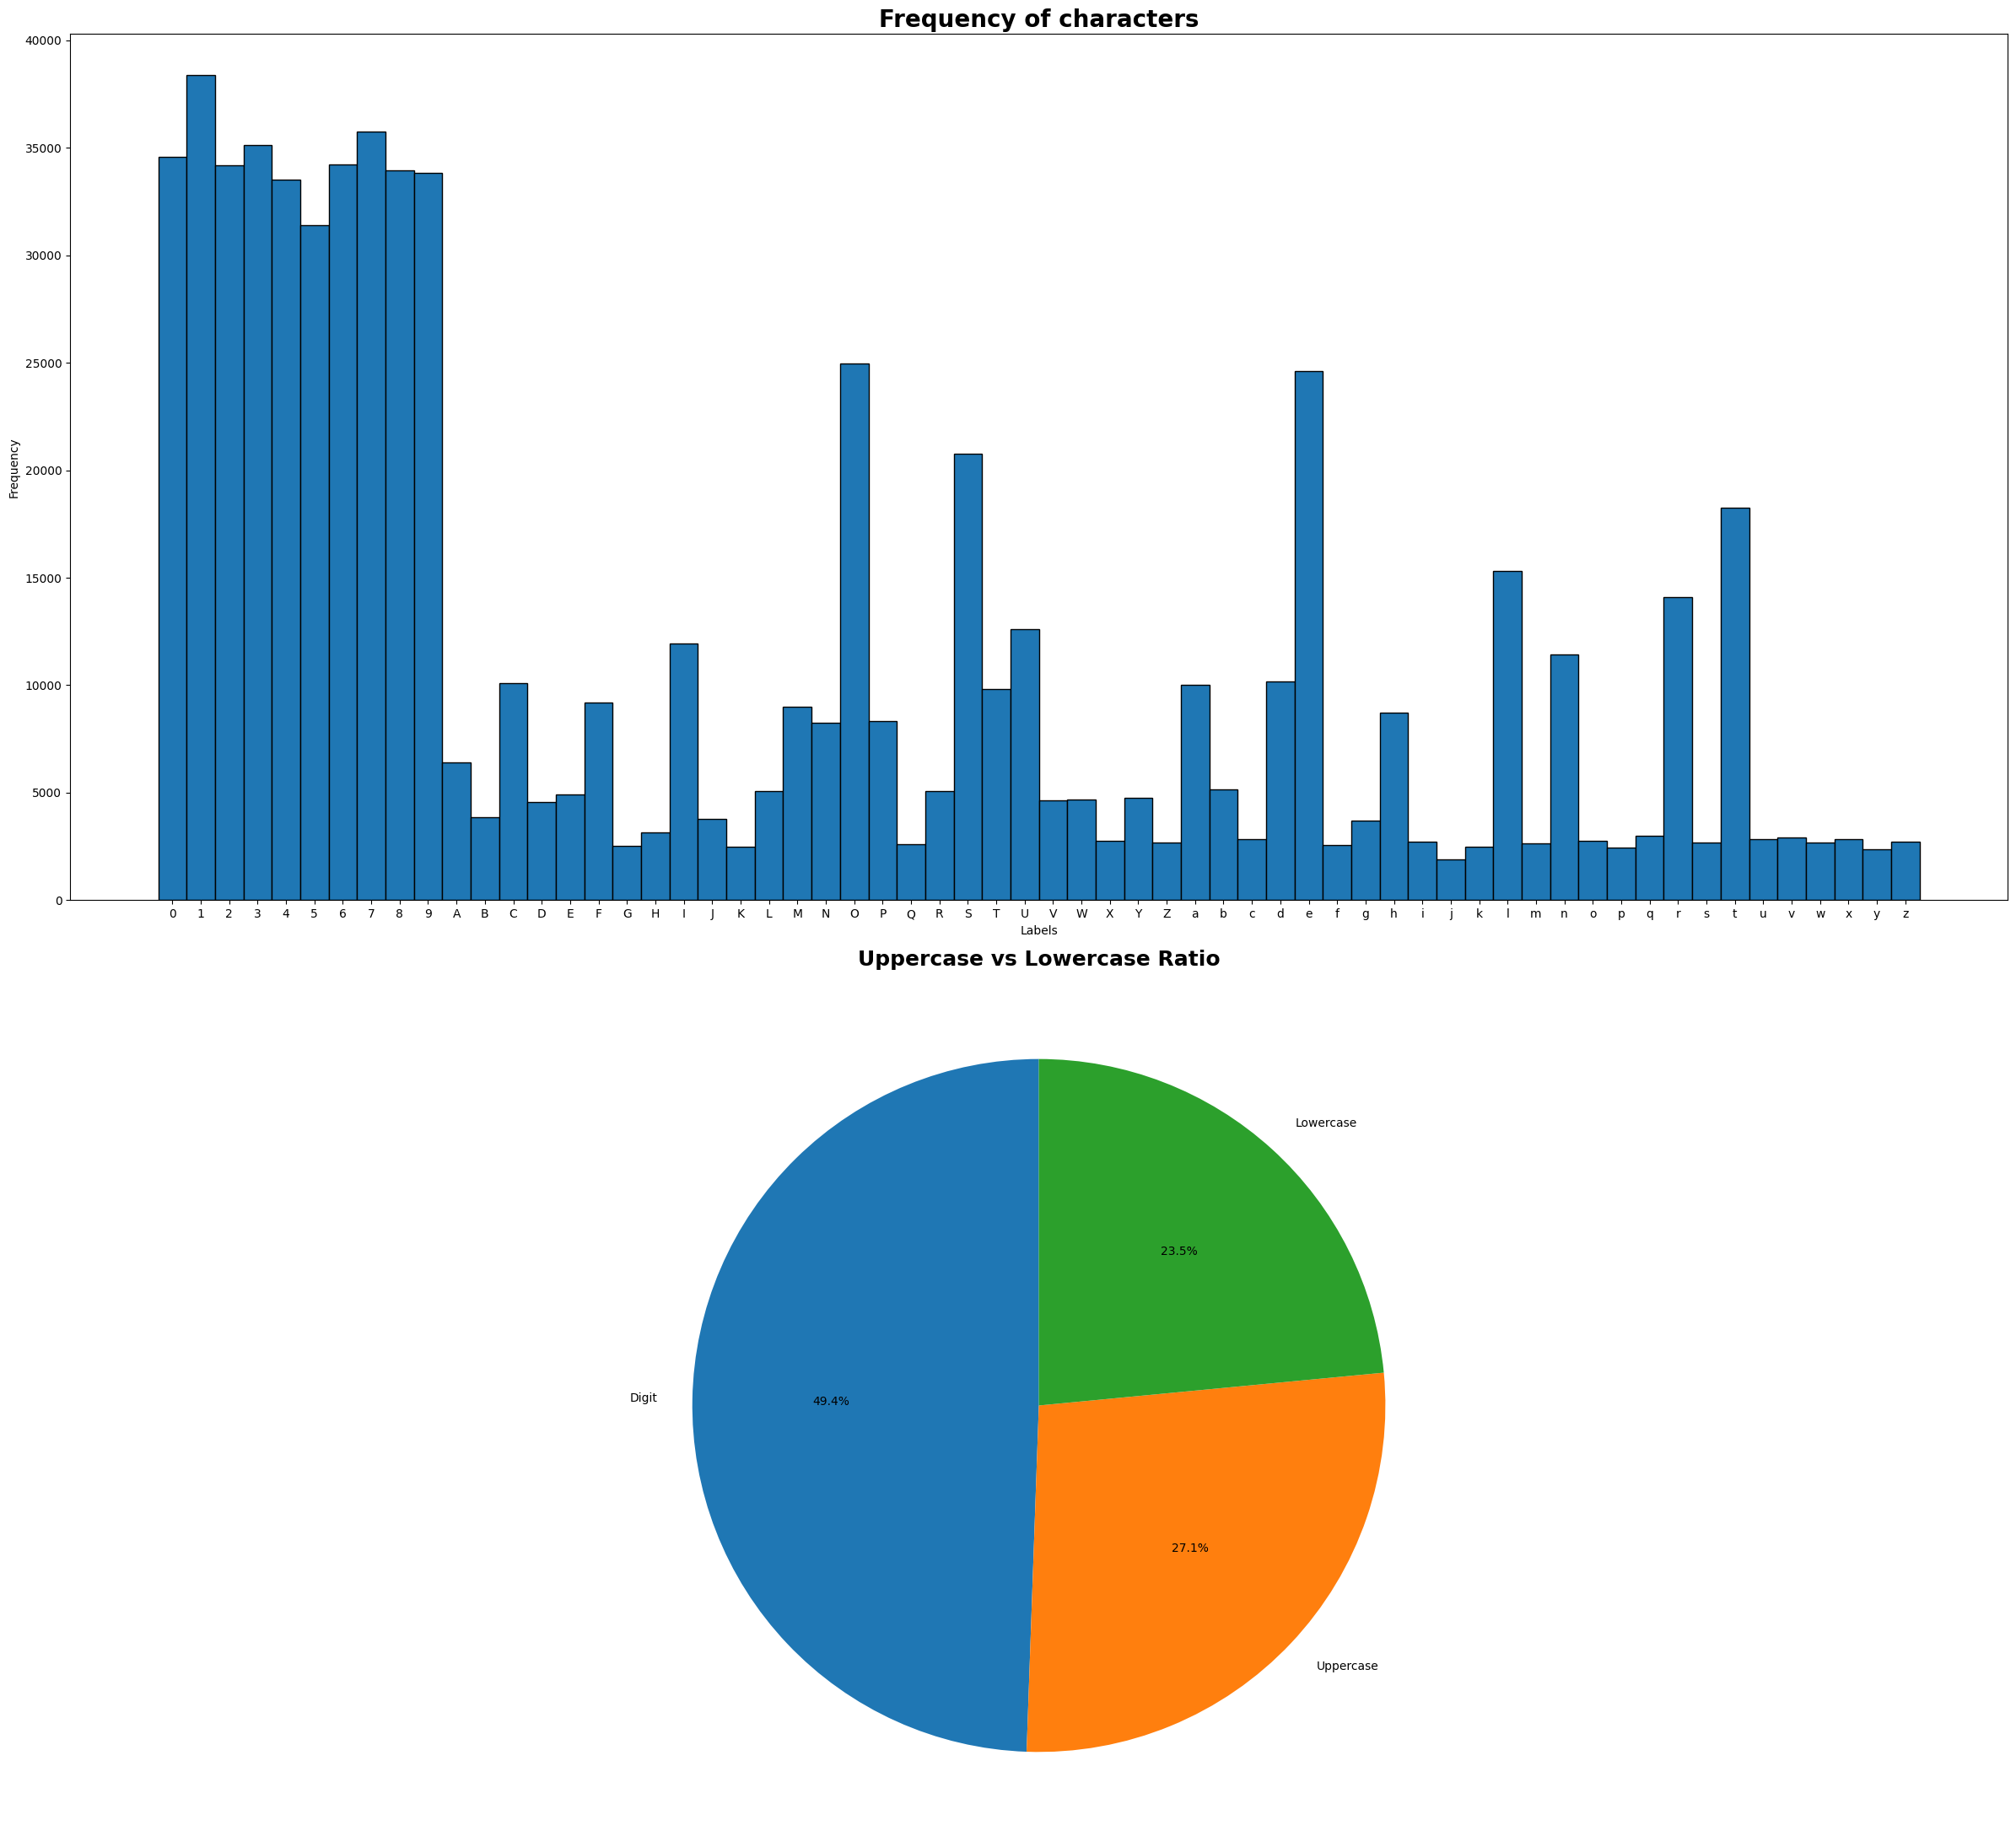

In [25]:
import matplotlib.pyplot as plt
import numpy as np

digit_count = np.sum((train_labels >= 0) & (train_labels <= 9))
upper_count = np.sum((train_labels >= 10) & (train_labels <= 35))
lower_count = np.sum((train_labels >= 36) & (train_labels <= 61))

labels_pie = ['Digit', 'Uppercase', 'Lowercase']
counts = [digit_count ,upper_count, lower_count]

fig, axes = plt.subplots(2, 1, figsize=(24, 22))

bins = np.arange(63) - 0.5
axes[0].hist(train_labels, bins=bins, edgecolor='black')

axes[0].set_xticks(range(62))
axes[0].set_xticklabels(mapping.values())
axes[0].set_xlabel('Labels')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Frequency of characters', fontsize=20, fontweight='bold')

axes[1].pie(
    counts,
    labels=labels_pie,
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Uppercase vs Lowercase Ratio', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()


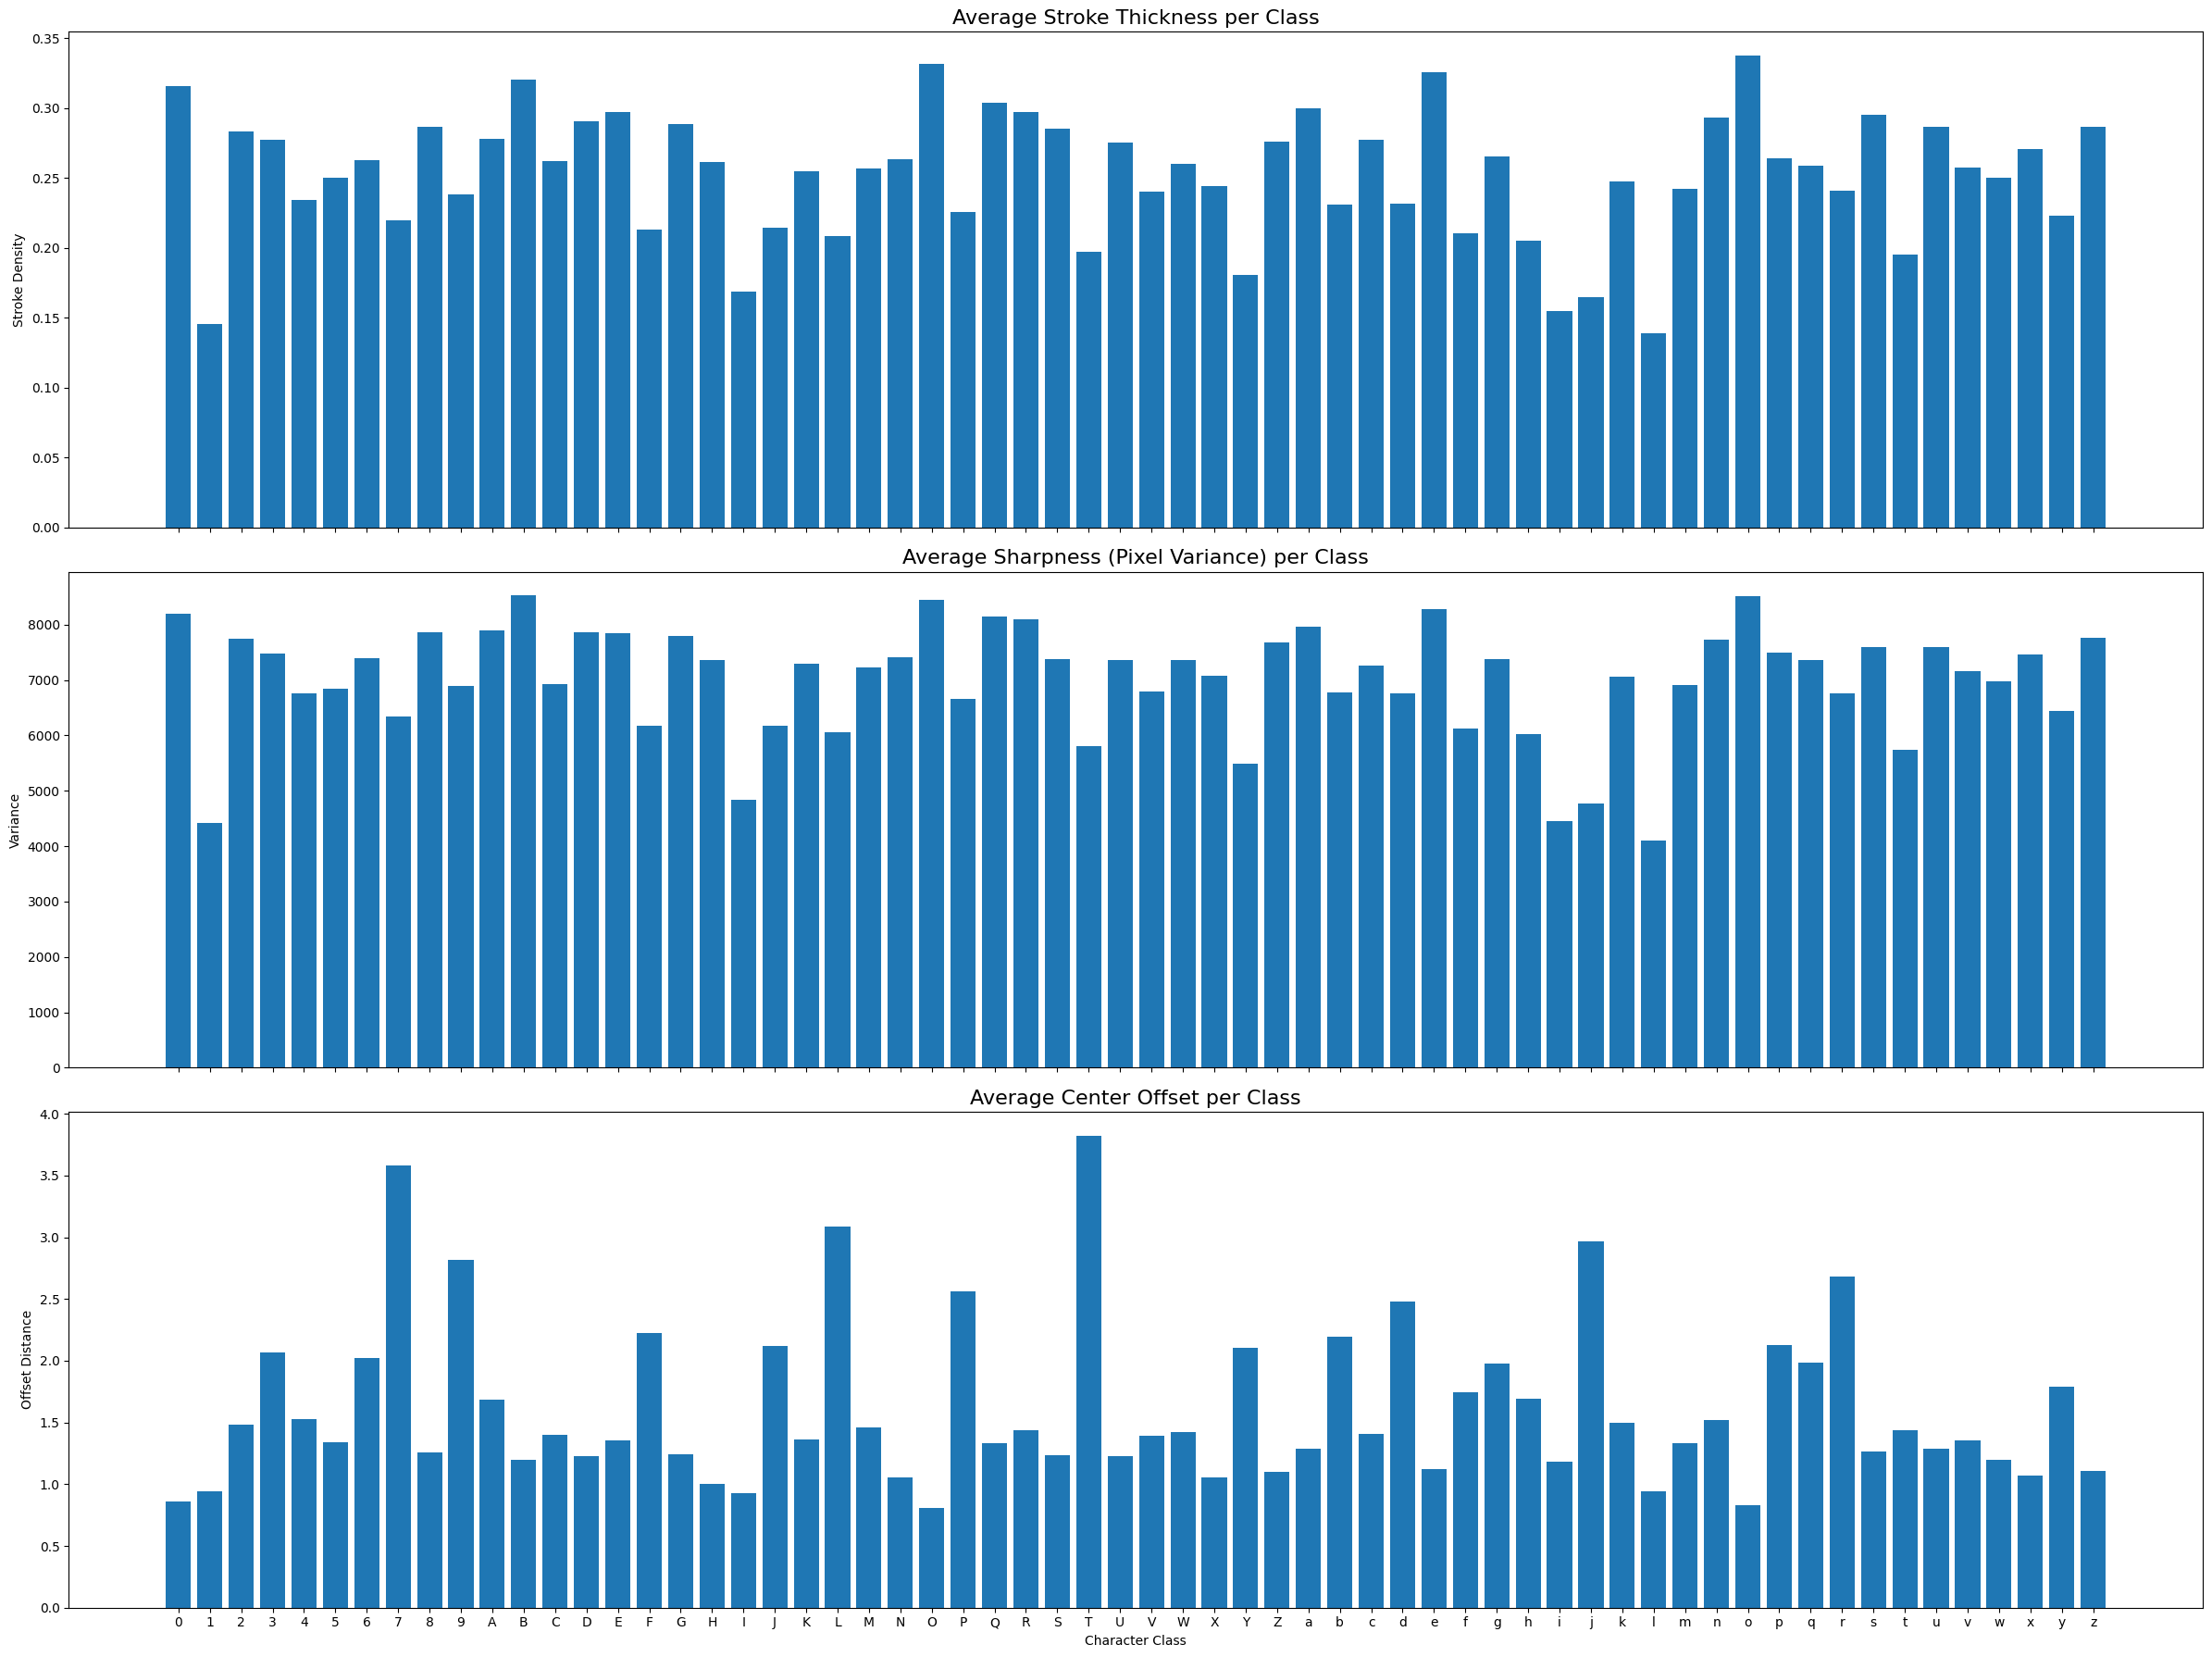

In [26]:
import numpy as np
import matplotlib.pyplot as plt

threshold = 30
stroke_density = (train_images > threshold).mean(axis=(1, 2))

sharpness = train_images.var(axis=(1, 2))

h, w = train_images.shape[1:]
Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

weights = train_images + 1e-6
total = weights.sum(axis=(1, 2))

cx = (weights * X).sum(axis=(1, 2)) / total
cy = (weights * Y).sum(axis=(1, 2)) / total

center_offset = np.sqrt((cx - w/2)**2 + (cy - h/2)**2)

num_classes = 62

stroke_mean = []
sharp_mean = []
center_mean = []

for c in range(num_classes):
    idx = train_labels == c
    stroke_mean.append(stroke_density[idx].mean())
    sharp_mean.append(sharpness[idx].mean())
    center_mean.append(center_offset[idx].mean())

fig, axes = plt.subplots(3, 1, figsize=(24, 18), sharex=True)

axes[0].bar(range(num_classes), stroke_mean)
axes[0].set_title('Average Stroke Thickness per Class', fontsize=16)
axes[0].set_ylabel('Stroke Density')

axes[1].bar(range(num_classes), sharp_mean)
axes[1].set_title('Average Sharpness (Pixel Variance) per Class', fontsize=16)
axes[1].set_ylabel('Variance')

axes[2].bar(range(num_classes), center_mean)
axes[2].set_title('Average Center Offset per Class', fontsize=16)
axes[2].set_ylabel('Offset Distance')

axes[2].set_xticks(range(num_classes))
axes[2].set_xticklabels(mapping.values())
axes[2].set_xlabel('Character Class')

plt.tight_layout()
plt.show()

